## Atividade 2 Métodos de Interpolação

# Exercícios Práticos para o método de Interpolação Polinomial de Hermite

## Exercício 1

Considere a tabela com os valores abaixo para resolver de forma numérica o problema de interpolação polinomial destes pontos, considerando os métodos:

* Newton
* Spline Cúbica Natural
* Hermite (com dois conjuntos diferentes para os valores das derivadas nos pontos)

## Tabela de dados

| i | $$x_i$$ | $$f(x_i)$$ | $$f'_1(x_i)$$ | $$f'_2(x_i)$$ |
| - | ------- | ---------- | ------------- | ------------- |
| 0 | -7.0    | -12.5      | 1.5           | 10.0          |
| 1 | -4.5    | 8.0        | 4.2           | -2.0          |
| 2 | -1.0    | 0.0        | -5.0          | 0.0           |
| 3 | 2.2     | -15.2      | 0.0           | -12.5         |
| 4 | 8.0     | 25.4       | 8.5           | 1.0           |
| 5 | 13.5    | 5.0        | -3.2          | -8.0          |
| 6 | 21.0    | 42.0       | 12.0          | 2.5           |
| 7 | 25.0    | 18.5       | -1.5          | -20.0         |


### a)

Realize um plot com todas as curvas obtidas pelos métodos para comparação.

In [105]:
import numpy as np
import matplotlib.pyplot as plt

xi = np.array([-7.0, -4.5, -1.0, 2.2, 8.0, 13.5, 21.0, 25.0])
yi = np.array([-12.5, 8.0, 0.0, -15.2, 25.4, 5.0, 42.0, 18.5])
dy1 = np.array([1.5, 4.2, -5.0, 0.0, 8.5, -3.2, 12.0, -1.5])
dy2 = np.array([10.0, -2.0, 0.0, -12.5, 1.0, -8.0, 2.5, -20.0])

In [106]:
def newton(xi, yi, x_alvo = None):
    n = len(xi)
    n_pontos = 100
    
    # caso x_alvo exista, o algoritmo trata o x_alvo
    # como um vetor unico, entao ele será isolado do restante
    if x_alvo is not None:
        x = np.atleast_1d(x_alvo)
    else:
        x = np.linspace(xi[0], xi[-1], 100)

    n_eval = len(x)

    D = np.zeros((n, n))

    D[:, 0] = yi
    for j in range(1, n):
        for i in range(j, n):
            D[i, j] = (D[i, j - 1] - D[i - 1, j - 1]) / (xi[i] - xi[i - j])

    c = np.diag(D)
    y = np.ones(n_eval) * c[0]
    xv = np.ones(n_eval)

    for j in range(1, n):
        xv *= (x - xi[j - 1])
        y += c[j] * xv

    return x, y

In [107]:
def splines(xi, yi, x_alvo = None):
    n = len(xi)
    n_pontos = 100 #numero de pontos da malha
    
    # caso x_alvo exista, o algoritmo trata o x_alvo
    # como um vetor unico, entao ele será isolado do restante
    if x_alvo is not None:
        x = np.atleast_1d(x_alvo)
    else:
        x = np.linspace(xi[0], xi[-1], 100)

    n_eval = len(x)

    m = n - 1 #subintervalos
    h = np.zeros(n - 1)

    for i in range(n - 1):
        h[i] = xi[i + 1] - xi[i]

    a = yi
    A = np.zeros((n, n))
    r = np.zeros(n)

    A[0, 0] = A[n - 1, n - 1] = 1

    for j in range(1, n - 1):
        A[j, j - 1] = h[j - 1]
        A[j, j] = 2 * h[j - 1] + h[j]
        A[j, j + 1] = h[j]
        r[j] = 3 * ((a[j + 1] - a[j]) / h[j] - (a[j] - a[j - 1]) / h[j - 1])

    c = np.linalg.solve(A, r)

    d = np.zeros(m)
    b = np.zeros(m)

    for j in range(m):
        d[j] = (c[j + 1] - c[j]) / (3 * h[j])
        b[j] = (a[j + 1] - a[j]) / h[j] - h[j] / 3 * (2 * c[j] + c[j + 1])

    y = np.zeros(n_eval)

    for k in range(n_eval):
        idx = m
        for j in range(m):
            if x[k] <= xi[j + 1]:
                idx = j
                break
        t = x[k] - xi[idx]
        y[k] = a[idx] + b[idx] * t + c[idx] * t ** 2 + d[idx] * t ** 3

    return x, y

In [108]:
def hermite(xi, yi, dyi, x_alvo = None):
    n = len(xi)
    n_pontos = 100
    
    if x_alvo is not None:
        x = np.atleast_1d(x_alvo)
    else:
        x = np.linspace(xi[0], xi[-1], 100)

    n_eval = len(x)

    L = np.ones((n, n_pontos))
    dL = np.zeros((n, 1))

    for i in range(n):
        for j in range(n):
            if i != j:
                L[i, :] *= ((x - xi[j]) / (xi[i] - xi[j]))

    for i in range(n):
        for k in range(n):
            if i != k:
                dL[i] += 1 / (xi[i] - xi[k])

    h = np.zeros((n, n_pontos))
    ht = np.zeros((n, n_pontos))

    for i in range(n):
        h[i, :] = (1 - 2 * (x - xi[i]) * dL[i]) * (L[i] ** 2)

        ht[i, :] = (x - xi[i]) * (L[i, :] ** 2)

    y = yi @ h + dyi @ ht

    return x, y

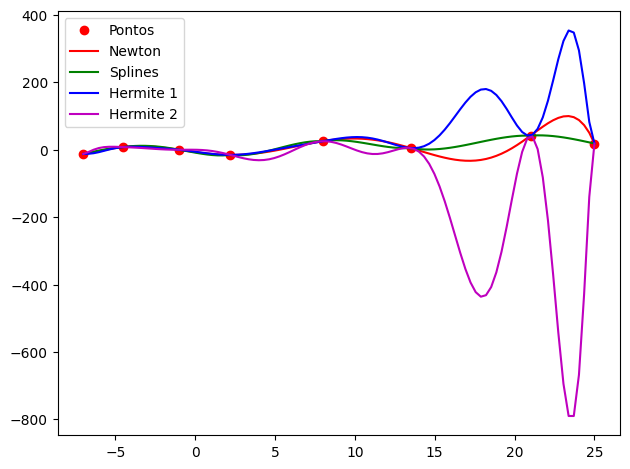

In [109]:
import matplotlib.pyplot as plt

plt.plot(xi, yi, "ro", label="Pontos")

x_new, y_new = newton(xi, yi)
plt.plot(x_new, y_new, "r-", label="Newton")

x_spl, y_spl = splines(xi, yi)
plt.plot(x_spl, y_spl, "g-", label="Splines")

x_herm, y_herm = hermite(xi, yi, dy1)
plt.plot(x_herm, y_herm, "b-", label="Hermite 1")

x_herm, y_herm = hermite(xi, yi, dy2)
plt.plot(x_herm, y_herm, "m-", label="Hermite 2")

plt.legend(loc="upper left")

plt.tight_layout()
plt.show()

### b)

Utilize os plots obtidos para aproximar o valor de $f(6)$

In [110]:
x_new, y_new = newton(xi, yi, 6)
print(f"f(6) = {y_new[0]}, Newton")
x_spl, y_spl = splines(xi, yi, 6)
print(f"f(6) = {y_spl[0]}, Splines")
x_herm, y_herm = hermite(xi, yi, dy1, 6)
print(f"f(6) = {y_herm[0]}, Hermite 1")
x_herm, y_herm = hermite(xi, yi, dy2, 6)
print(f"f(6) = {y_herm[0]}, Hermite 2")

f(6) = 6.931955942174414, Newton
f(6) = 13.701230891267912, Splines
f(6) = 8.723348132141934, Hermite 1
f(6) = -5.000129018615496, Hermite 2
